In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn
cwd = Path('.')

In [2]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data = pd.read_csv(data_path,index_col=0)
data_len = int(len(data) * 10 / 12)

C:\Users\victo\AppData\Local\Temp\ipykernel_15556\4154608675.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path,index_col=0)


In [3]:
data = data.drop(data[data["position"] == "team"].index) 

# Using frequent itemsets to find champ synergies

In [4]:
pick_set = []
ban_set = []
result = []

for i in tqdm(range(0,len(data),5)):
    data_game = data.iloc[i:i+5]
    picked = (data_game["champion"] + "_picked").values
    picked = picked[~pd.isnull(picked)]
    banned = (data_game.iloc[0][["ban1", "ban2","ban3","ban4","ban5"]] + "_banned").values
    banned = banned[~pd.isnull(banned)]
    pick_set.append(picked)
    ban_set.append(banned)
    result.append(data_game.iloc[0]["result"])


  0%|          | 0/20106 [00:00<?, ?it/s]

In [240]:
def get_pick_ban(game_data):
        picked = (data_game["champion"] + "_picked").values
        picked = picked[~pd.isnull(picked)]
        banned = (data_game.iloc[0][["ban1", "ban2","ban3","ban4","ban5"]] + "_banned").values
        banned = banned[~pd.isnull(banned)]

        return picked,banned 

fullmatch_pick_set = []
fullmatch_ban_set = []
fullmatch_result = []

for i in tqdm(range(0,len(data),10)):


    team1 = data.iloc[i:i+5]
    team1_picked,team1_banned = get_pick_ban(team1)

    team2 = data.iloc[i+5:i+10]
    team2_picked,team2_banned = get_pick_ban(team2)

    fullmatch_pick_set.append((team1_picked + "_team1") + (team2_picked + "_team2"))
    fullmatch_ban_set.append((team1_banned + "_team1") + (team2_banned + "_team2"))
    result.append(team1.iloc[0]["result"])
    result.append(team2.iloc[0]["result"])
    

    fullmatch_pick_set.append((team2_picked + "_team1") + (team1_picked + "_team2"))
    fullmatch_ban_set.append((team2_banned + "_team1") + (team1_banned + "_team2"))


  0%|          | 0/10053 [00:00<?, ?it/s]

In [ ]:
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(pick_set).transform(pick_set)
df_ap = pd.DataFrame(te_ary, columns=te.columns_)
from mlxtend.frequent_patterns import fpgrowth
frequent_itemsets = fpgrowth(df_ap, min_support=0.01,use_colnames=True)

We need to use a very low support to get sets of a size greater than 1 since there are only ever 5 champions and very many combinations of them.

In [29]:
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
freq_greater_1 = frequent_itemsets[(frequent_itemsets['length'])>1]
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(freq_greater_1.sort_values(by=["support"])[-20:])

      support                           itemsets  length
190  0.016861     (Ambessa_picked, Varus_picked)       2
139  0.016960  (Xin Zhao_picked, Alistar_picked)       2
171  0.016960    (Xin Zhao_picked, Rakan_picked)       2
130  0.017109    (Nautilus_picked, Varus_picked)       2
153  0.017457   (Taliyah_picked, Alistar_picked)       2
144  0.017457      (Rell_picked, Taliyah_picked)       2
197  0.017507   (Xin Zhao_picked, Rumble_picked)       2
111  0.017607     (Xin Zhao_picked, Azir_picked)       2
193  0.017806    (Rumble_picked, Alistar_picked)       2
189  0.018104      (Ambessa_picked, Rell_picked)       2
97   0.018552    (Xin Zhao_picked, Varus_picked)       2
183  0.018950           (Ahri_picked, Vi_picked)       2
203  0.018950      (Sejuani_picked, Yone_picked)       2
206  0.019646     (Rell_picked, Xin Zhao_picked)       2
147  0.020392  (Xin Zhao_picked, Taliyah_picked)       2
192  0.020790       (Rell_picked, Rumble_picked)       2
89   0.022481      (Leona_picke

Xayah and Rakan are a well known combo with high synergy so seeing them with the highest support is good, but looking at the other picks we see stuff like "Xin Zhao" + "Rumble" and "Xin Zhao" + "Azir", which aren't synergies but are just combinations of popular champions. The result is promising though, and also shows other synergies that might not be very well known such as "Ahri" + "Vi" and "Rell" + "Rumble". Let's try to normalize the support based on the champions' individual popularity, such that we only find synergies rather than popular champions. 

Let $\sigma(\{c\})$ be the percentage support of the itemset with a single champion $c$, then, assuming two champions $c_1, c_2$ are picked independently (and thus do not synergize), the support of their joint itemset ${c_1, c_2}$ would be $\sigma(\{c_1\})\sigma(\{c_2\})$. The actual joint support $\sigma(\{c_1, c_2\})$ will thus be higher than $\sigma(\{c_1\})\sigma(\{c_2\})$ if they synergize, and lower otherwise.

We thus calculate what we call the normalize support for all itemsets:

$$
\sigma(\{c_1, c_2\})_{norm} = \frac{\sigma(\{c_1, c_2\})}{\sigma(\{c_1\})\sigma(\{c_2\})}
$$

We then sort by the normalized support to find synergies:

In [ ]:
norms = []
for pick_index in range(len(freq_greater_1)):
    k = 1
    for i in freq_greater_1.iloc[pick_index]["itemsets"]:
        k = k * frequent_itemsets[frequent_itemsets["itemsets"]==set([i])]["support"].iloc[0]
    norm_support = freq_greater_1.iloc[pick_index]["support"] / k
    norms.append(norm_support)
freq_greater_1["norm_support"] = norms

with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(freq_greater_1.sort_values(by=["norm_support"])[-20:])

      support                               itemsets  length  norm_support
140  0.011340             (Vi_picked, Aurora_picked)       2      1.522731
202  0.016612     (Rell_picked, Miss Fortune_picked)       2      1.531942
198  0.013876           (Jhin_picked, Rumble_picked)       2      1.533664
161  0.013081          (Jayce_picked, Ezreal_picked)       2      1.544245
214  0.016264            (Vi_picked, Taliyah_picked)       2      1.555928
224  0.013130      (Pantheon_picked, Taliyah_picked)       2      1.617923
215  0.015667             (Vi_picked, Kai'Sa_picked)       2      1.733768
89   0.022481          (Leona_picked, Ezreal_picked)       2      1.959989
143  0.010843          (Skarner_picked, Azir_picked)       2      2.083640
204  0.014125           (Rumble_picked, Yone_picked)       2      2.086711
95   0.010544          (Jayce_picked, Maokai_picked)       2      2.220280
187  0.012583          (Kai'Sa_picked, Neeko_picked)       2      2.230098
183  0.018950            

C:\Users\victo\AppData\Local\Temp\ipykernel_15556\2477978070.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  freq_greater_1["norm_support"] = norms


Now we only see actual synergies, at the bottom we have the most well known synergy in pro play "Lucian" + "Nami", and all the other most synergies with the highest normalized supports are well known picks that pro players often center their compositions around, such as "Orianna" + "Nocturne". This also makes ones that aren't immediately obvious very interesting, such as "Kaisa" + "Neeko" and "Jayce" + "Maokai" (This one is probably for very long range poke compositions). 

Let's check the winrates to see if synergies correlate with winrate. 

In [31]:
wins = []
totals = []
winrate = []
for i in tqdm(range(len(freq_greater_1))):
    win = 0.0
    
    total = 0.0
    itemsets = freq_greater_1.iloc[i]["itemsets"]
    for game_index in range(len(pick_set)):
        if set(itemsets).intersection(set(pick_set[game_index])) == set(itemsets):
            win += result[game_index]
            total += 1.0
    wins.append(win)
    totals.append(total)
    winrate.append(win / total)
freq_greater_1["wr"] = winrate
freq_greater_1["wins"] = wins
freq_greater_1["totals"] = totals

  0%|          | 0/148 [00:00<?, ?it/s]

C:\Users\victo\AppData\Local\Temp\ipykernel_15556\2548085131.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  freq_greater_1["wr"] = winrate
C:\Users\victo\AppData\Local\Temp\ipykernel_15556\2548085131.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  freq_greater_1["wins"] = wins
C:\Users\victo\AppData\Local\Temp\ipykernel_15556\2548085131.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

In [41]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(freq_greater_1.sort_values(by=["norm_support"])[["norm_support", "itemsets", "wr", "totals"]][-20:])

     norm_support                               itemsets        wr  totals
140      1.522731             (Vi_picked, Aurora_picked)  0.451754   228.0
202      1.531942     (Rell_picked, Miss Fortune_picked)  0.508982   334.0
198      1.533664           (Jhin_picked, Rumble_picked)  0.501792   279.0
161      1.544245          (Jayce_picked, Ezreal_picked)  0.539924   263.0
214      1.555928            (Vi_picked, Taliyah_picked)  0.599388   327.0
224      1.617923      (Pantheon_picked, Taliyah_picked)  0.526515   264.0
215      1.733768             (Vi_picked, Kai'Sa_picked)  0.555556   315.0
89       1.959989          (Leona_picked, Ezreal_picked)  0.469027   452.0
143      2.083640          (Skarner_picked, Azir_picked)  0.513761   218.0
204      2.086711           (Rumble_picked, Yone_picked)  0.559859   284.0
95       2.220280          (Jayce_picked, Maokai_picked)  0.495283   212.0
187      2.230098          (Kai'Sa_picked, Neeko_picked)  0.584980   253.0
183      2.410885        

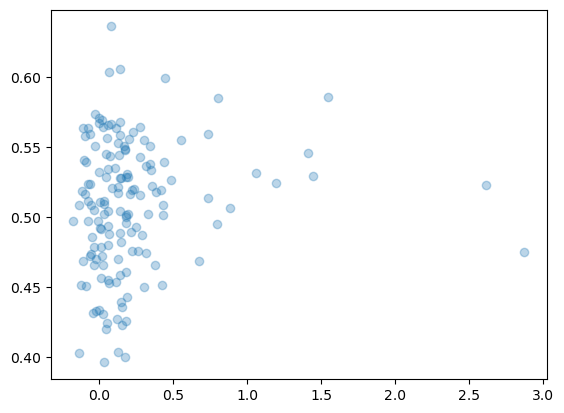

In [67]:
plt.scatter(np.log(freq_greater_1["norm_support"]), freq_greater_1["wr"], alpha=0.3)
plt.show()

We find that the most well known synergy actually has below $50\%$ winrate, which might explain why it has been falling out of favor in pro play despite being so well known. In general, the synergies seem to be performing quite well. 

Next we'll look into frequent item associations of picks and bans, is there a tendency to ban particular champions when picking certain champions? This might tell us which matchups the pro players consider to be "counter matchups" (extremely difficult matchups to play), which they thus ban to avoid. 

In [56]:
pick_ban_set = [] # First is champ selected, second is ban
for i in range(len(pick_set)):
    pick_ban_set.append(np.concat([pick_set[i],ban_set[i]]))

te = TransactionEncoder()
te_ary = te.fit(pick_ban_set).transform(pick_ban_set)
df_ap_pb = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets_pb = fpgrowth(df_ap_pb, min_support=0.01,use_colnames=True)

In [60]:
frequent_itemsets_pb['length'] = frequent_itemsets_pb['itemsets'].apply(lambda x: len(x))
freq_greater_1_pb = frequent_itemsets_pb[(frequent_itemsets_pb['length'])>1]
common_pick_ban = freq_greater_1_pb.sort_values(by=["support"])

norms = []
for pick_ban_index in range(len(common_pick_ban)):
    k = 1
    for i in common_pick_ban.iloc[pick_ban_index]["itemsets"]:
        k = k * frequent_itemsets_pb[frequent_itemsets_pb["itemsets"]==set([i])]["support"].iloc[0]
    norm_support = common_pick_ban.iloc[pick_ban_index]["support"] / k
    norms.append(norm_support)
common_pick_ban["norm_support"] = norms

We filter so that we only get the frequent itemsets that contain at least one pick and one ban. 

In [54]:
indices = []
for itemset in common_pick_ban["itemsets"]:
    indices.append(np.any(["banned" in x for x in itemset]) and np.any(["picked" in x for x in itemset]))

In [ ]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(common_pick_ban.iloc[indices].sort_values(by=["norm_support"])[-15:])

      support                             itemsets  length  norm_support
344  0.016065     (Ambessa_banned, K'Sante_picked)       2      1.566485
888  0.010246    (Trundle_banned, Xin Zhao_picked)       2      1.567356
739  0.015319        (Ezreal_banned, Varus_picked)       2      1.576801
864  0.011091     (Poppy_banned, Jarvan IV_picked)       2      1.609446
583  0.010196         (Braum_picked, Rakan_banned)       2      1.777158
858  0.027902           (Sion_picked, Gwen_banned)       2      1.809530
594  0.011340          (Rell_banned, Leona_picked)       2      1.824497
684  0.012882       (Kai'Sa_banned, Ezreal_picked)       2      1.826377
635  0.022829        (Rell_picked, Alistar_banned)       2      1.865075
702  0.015816         (Braum_banned, Leona_picked)       2      1.892520
890  0.013031    (Pantheon_banned, Trundle_picked)       2      1.905597
700  0.017756      (Nautilus_picked, Braum_banned)       2      1.918799
669  0.012335  (Miss Fortune_picked, Braum_banned) 

This gives us common counterpicks, with "Ambessa" - "Renekton" being one of the big ones as "Renekton" can destroy the shield "Ambessa" uses to fight. Most of these are very well known, an interesting one might be "Ezreal" - "Kai'sa", which we were not aware of. 

We can also check the winrates, when pro players counterpick does it increase theri chance to win? 

In [63]:
wins = []
totals = []
winrate = []
for i in tqdm(range(len(common_pick_ban))):
    win = 0.0
    
    total = 0.0
    itemsets = common_pick_ban.iloc[i]["itemsets"]
    for game_index in range(len(pick_ban_set)):
        if set(itemsets).intersection(set(pick_ban_set[game_index])) == set(itemsets):
            win += result[game_index]
            total += 1.0
    wins.append(win)
    totals.append(total)
    winrate.append(win / total)

common_pick_ban["wr"] = winrate
common_pick_ban["wins"] = wins
common_pick_ban["totals"] = totals


  0%|          | 0/725 [00:00<?, ?it/s]

In [65]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(common_pick_ban.iloc[indices].sort_values(by=["norm_support"])[-15:][["itemsets", "norm_support", "wr", "totals"]])

                                itemsets  norm_support        wr  totals
344     (Ambessa_banned, K'Sante_picked)      1.566485  0.445820   323.0
888    (Trundle_banned, Xin Zhao_picked)      1.567356  0.490291   206.0
739        (Ezreal_banned, Varus_picked)      1.576801  0.538961   308.0
864     (Poppy_banned, Jarvan IV_picked)      1.609446  0.515695   223.0
583         (Braum_picked, Rakan_banned)      1.777158  0.531707   205.0
858           (Sion_picked, Gwen_banned)      1.809530  0.461676   561.0
594          (Rell_banned, Leona_picked)      1.824497  0.456140   228.0
684       (Kai'Sa_banned, Ezreal_picked)      1.826377  0.505792   259.0
635        (Rell_picked, Alistar_banned)      1.865075  0.514161   459.0
702         (Braum_banned, Leona_picked)      1.892520  0.465409   318.0
890    (Pantheon_banned, Trundle_picked)      1.905597  0.488550   262.0
700      (Nautilus_picked, Braum_banned)      1.918799  0.487395   357.0
669  (Miss Fortune_picked, Braum_banned)      2.056

And we see that these winrates are not good. This probably means that there is always a trade going on, if you use a ban to secure a strong pick you'll be giving something somewhere else. Now what if someone just picks a strong pick and doesn't ban their counter, so they get counterpicked? Can we find counterpicks and see how big of an effect they have? Let's try finding normalized frequent itemsets between two teams.   








Can look more into counter picks (IE make each entry the laners for a given game on opposing sides), seperate by whether the team won or not, add a league or patch to see if a champ is really popular in a certain patch or league (could also seperate those into their own subdatasets). Look at the class roles (Tank, Mage etc), llok more clearly at pick ban, IE make the variables "Varus_picked" and "Varus_banned". Normalize by popularity see above